08 — Analysis: ablations, failure modes, and the remaining gap

This notebook ties everything together for the report. It expects that
`scripts/train_all.py` has already produced the metrics JSONs for both feature
sets:

- `results/metrics/models_engineered.json`
- `results/metrics/models_raw.json`

Run them with:

```
python -m scripts.train_all --config configs/default.yaml --feature-set engineered
python -m scripts.train_all --config configs/default.yaml --feature-set raw \
--skip arima lstm
```

(We skip ARIMA and LSTM in the raw ablation: ARIMA does not use feature columns,
and LSTM with only the 5 raw columns has no signal worth measuring.)

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import os
os.environ.setdefault("MPLCONFIGDIR", str(__import__("pathlib").Path.cwd() / ".mplcache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.viz.style import set_style, save_figure, PRIMARY, ACCENT, SUPPORT

set_style()
PLOT_DIR = Path("../results/plots/analysis")
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def load_metrics(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)


eng = load_metrics("../results/metrics/models_engineered.json")
raw = load_metrics("../results/metrics/models_raw.json")


1. Headline comparison

Every model in one table — RMSE, CV-RMSE, training time.

In [2]:
def metrics_table(payload: dict) -> pd.DataFrame:
    rows = []
    for name, m in payload["models"].items():
        rows.append({
            "model": name, "family": m["family"],
            "rmse": m["metrics"]["rmse"],
            "cv_rmse": m["metrics"]["cv_rmse"],
            "mae": m["metrics"]["mae"],
            "train_seconds": m["train_seconds"],
        })
    bl = payload.get("baselines", {})
    for k, v in bl.items():
        rows.append({
            "model": f"baseline_{k}", "family": "baseline",
            "rmse": v["metrics"].get("rmse"),
            "cv_rmse": v["metrics"].get("cv_rmse"),
            "mae": v["metrics"].get("mae"),
            "train_seconds": 0.0,
        })
    return pd.DataFrame(rows).sort_values("rmse")


eng_table = metrics_table(eng)
raw_table = metrics_table(raw)
eng_table


,model,family,rmse,cv_rmse,mae,train_seconds
8,arima,time_series,1086.840530,1.854170,440.597704,2366.460363
5,random_forest,trees,4314.850354,5.717182,145.976246,918.490913
4,decision_tree,trees,4990.566721,6.612507,176.390171,92.710856
6,lightgbm,trees,5721.912952,7.581542,200.739155,0.000000
2,lasso,linear,6232.327201,8.257841,674.447157,10.612549
3,elasticnet,linear,6379.182566,8.452425,676.209061,52.941347
0,ols,linear,6428.948550,8.518365,676.585758,3.812806
1,ridge,linear,6429.358782,8.518909,676.588221,10.823676
7,mlp,neural,10068.625829,13.340942,382.567871,0.000000
9,lstm,time_series,19125.476705,18.766241,729.712003,468.157727


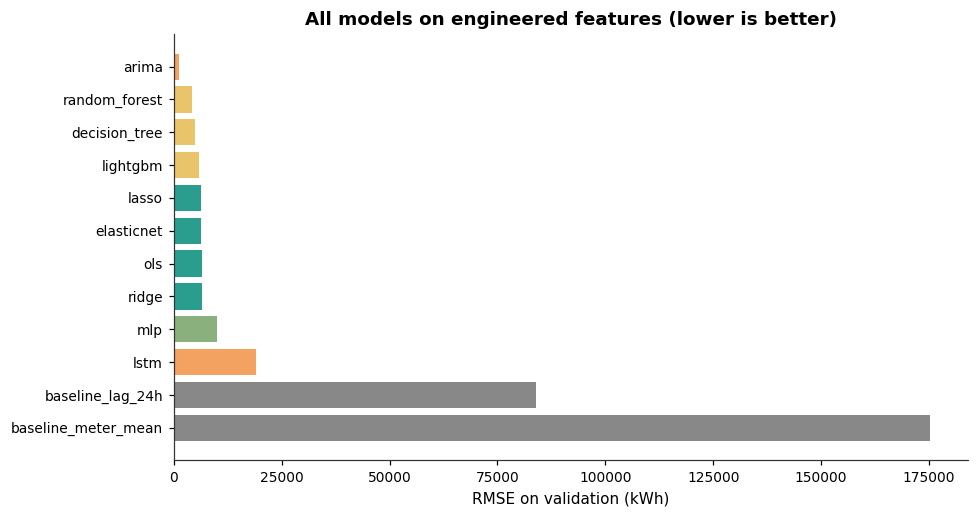

In [3]:
fig, ax = plt.subplots(figsize=(9, max(3.5, 0.4 * len(eng_table))))
fam_colors = {"baseline": "#888", "linear": SUPPORT[0], "trees": SUPPORT[1],
              "time_series": SUPPORT[2], "neural": SUPPORT[3]}
colors = [fam_colors.get(f, PRIMARY) for f in eng_table["family"]]
ax.barh(eng_table["model"][::-1], eng_table["rmse"][::-1], color=colors[::-1])
ax.set_xlabel("RMSE on validation (kWh)")
ax.set_title("All models on engineered features (lower is better)")
plt.tight_layout()
save_figure(fig, PLOT_DIR / "all_models_rmse")
plt.show()


2. Ablation: 5 raw features vs. 28 engineered features

The proposal predicts that the gap between linear models and LightGBM shrinks
substantially with engineered features, because most of what feature engineering
encodes (lags, rolling stats, target encoding, cyclical time) is something tree
ensembles can also learn from raw inputs to some degree.

In [4]:
def ablation_pivot(eng_table: pd.DataFrame, raw_table: pd.DataFrame) -> pd.DataFrame:
    e = eng_table.set_index("model")["rmse"].rename("engineered")
    r = raw_table.set_index("model")["rmse"].rename("raw")
    out = pd.concat([e, r], axis=1)
    out["delta"] = out["raw"] - out["engineered"]
    out["pct_improvement"] = out["delta"] / out["raw"] * 100
    return out.dropna(subset=["engineered", "raw"]).sort_values("pct_improvement", ascending=False)


ablation = ablation_pivot(eng_table, raw_table)
ablation


,engineered,raw,delta,pct_improvement
model,,,,
random_forest,4314.850354,30833.666812,26518.816458,86.006042
decision_tree,4990.566721,30844.880786,25854.314065,83.820438
lightgbm,5721.912952,28951.044948,23229.131996,80.235902
lstm,19125.476705,26631.459366,7505.982660,28.184646
lasso,6232.327201,7046.342831,814.015630,11.552314
mlp,10068.625829,11251.593014,1182.967185,10.513775
elasticnet,6379.182566,7045.860281,666.677715,9.461978
ols,6428.948550,7032.922042,603.973492,8.587803
ridge,6429.358782,7032.923279,603.564497,8.581986


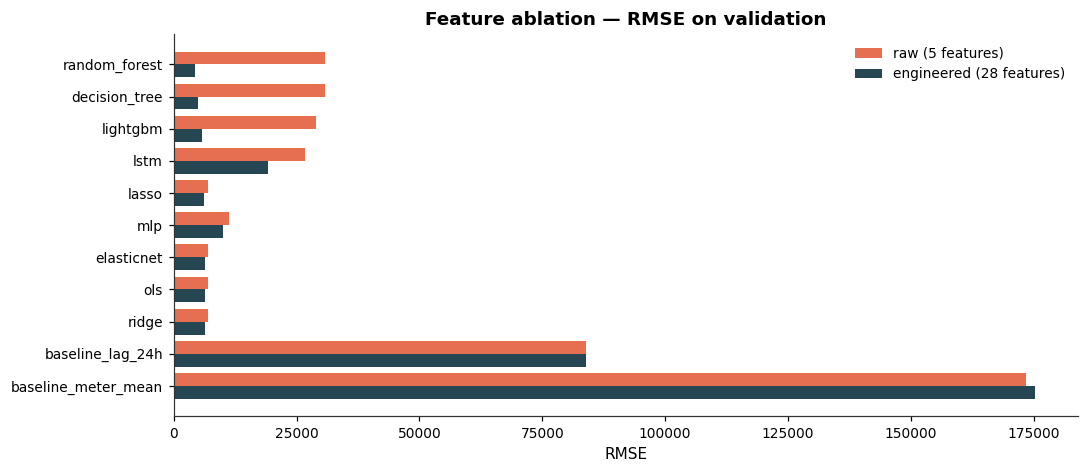

In [5]:
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.4 * len(ablation))))
order = ablation.index[::-1]
x = np.arange(len(order))
width = 0.4
ax.barh(x + width / 2, ablation.loc[order, "raw"], height=width,
        color=ACCENT, label="raw (5 features)")
ax.barh(x - width / 2, ablation.loc[order, "engineered"], height=width,
        color=PRIMARY, label="engineered (28 features)")
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("RMSE")
ax.set_title("Feature ablation — RMSE on validation")
ax.legend()
plt.tight_layout()
save_figure(fig, PLOT_DIR / "ablation_rmse")
plt.show()


3. Per-primary-use breakdown (engineered)

Where do the wins concentrate? We expect Education and Office (regular schedules)
to be cheap to predict; Lodging and Healthcare to expose where simpler models
fail.

In [6]:
def per_use_pivot(payload: dict) -> pd.DataFrame:
    rows = []
    for name, m in payload["models"].items():
        for r in m.get("by_primary_use", []):
            rows.append({"model": name, **r})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.pivot_table(index="primary_use", columns="model", values="rmse")


pu_eng = per_use_pivot(eng)
pu_eng.round(0)


model,arima,decision_tree,elasticnet,lasso,lightgbm,lstm,mlp,ols,random_forest,ridge
primary_use,,,,,,,,,,
Education,105.0,8360.0,9604.0,9320.0,9530.0,25348.0,16733.0,9703.0,7231.0,9703.0
Entertainment/public assembly,2790.0,295.0,691.0,700.0,291.0,3288.0,355.0,686.0,281.0,686.0
Food sales and service,NaN,300.0,798.0,798.0,352.0,39.0,523.0,799.0,291.0,799.0
Healthcare,66.0,522.0,1927.0,1940.0,505.0,95.0,925.0,1919.0,437.0,1919.0
Lodging/residential,NaN,686.0,1857.0,1861.0,703.0,163.0,1002.0,1855.0,665.0,1855.0
Manufacturing/industrial,NaN,214.0,645.0,646.0,197.0,NaN,261.0,646.0,192.0,646.0
Office,615.0,819.0,4055.0,4067.0,1073.0,123.0,2324.0,4044.0,684.0,4044.0
Other,NaN,43.0,208.0,207.0,39.0,NaN,105.0,208.0,38.0,208.0
Parking,72.0,200.0,1008.0,1024.0,247.0,112.0,504.0,995.0,176.0,995.0


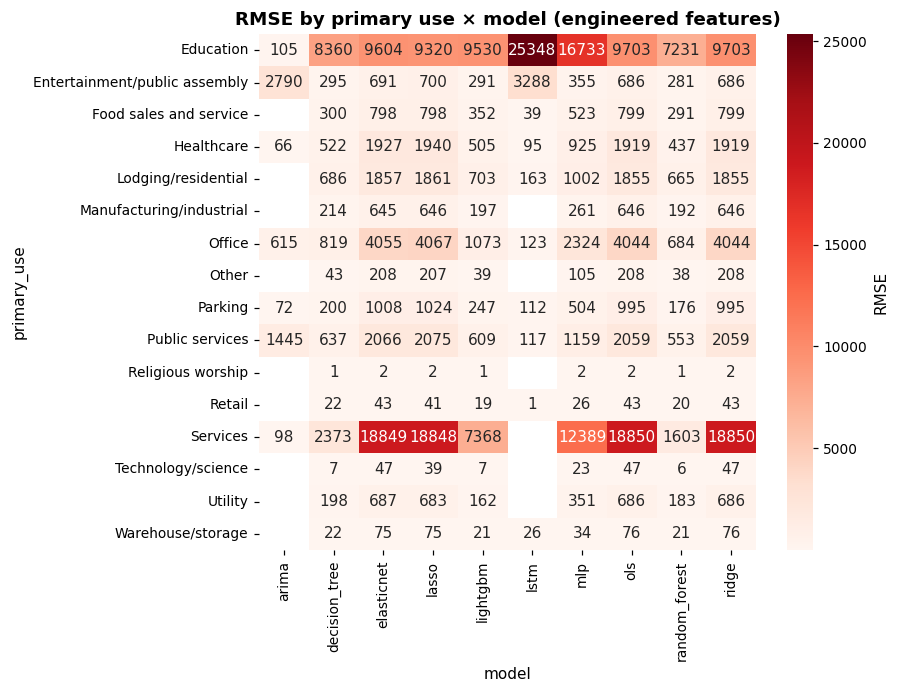

In [7]:
if not pu_eng.empty:
    fig, ax = plt.subplots(figsize=(min(13, 1.2 + 0.7 * len(pu_eng.columns)),
                                    max(4, 0.4 * len(pu_eng))))
    sns.heatmap(pu_eng, annot=True, fmt=".0f", cmap="Reds", ax=ax,
                cbar_kws={"label": "RMSE"})
    ax.set_title("RMSE by primary use × model (engineered features)")
    plt.tight_layout()
    save_figure(fig, PLOT_DIR / "per_primary_use_heatmap")
    plt.show()


4. Per-meter-type breakdown (engineered)

In [8]:
def per_meter_pivot(payload: dict) -> pd.DataFrame:
    rows = []
    for name, m in payload["models"].items():
        for r in m.get("by_meter", []):
            rows.append({"model": name, **r})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.pivot_table(index="meter_name", columns="model", values="rmse")


pm_eng = per_meter_pivot(eng)
pm_eng.round(0)


model,arima,decision_tree,elasticnet,lasso,lightgbm,lstm,mlp,ols,random_forest,ridge
meter_name,,,,,,,,,,
chilledwater,105.0,4432.0,3754.0,3755.0,3304.0,870.0,3823.0,3754.0,2511.0,3754.0
electricity,73.0,44.0,242.0,234.0,44.0,534.0,93.0,247.0,39.0,247.0
hotwater,1250.0,397.0,576.0,577.0,384.0,45865.0,430.0,574.0,387.0,574.0
steam,2123.0,12006.0,16341.0,15928.0,14691.0,NaN,26502.0,16480.0,11068.0,16481.0


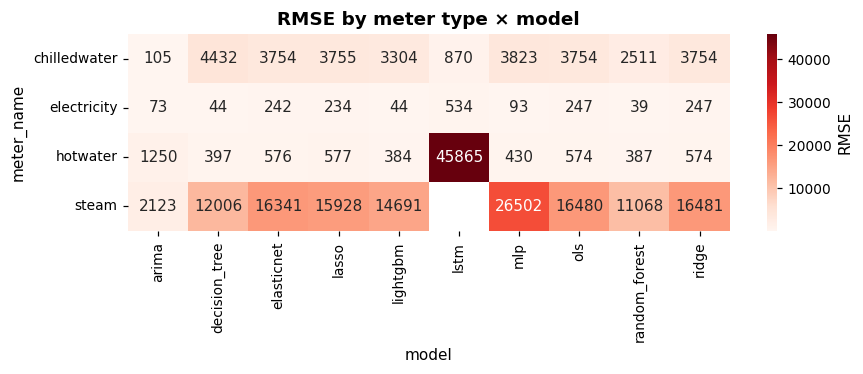

In [9]:
if not pm_eng.empty:
    fig, ax = plt.subplots(figsize=(min(13, 1.2 + 0.7 * len(pm_eng.columns)),
                                    max(3.5, 0.5 * len(pm_eng))))
    sns.heatmap(pm_eng, annot=True, fmt=".0f", cmap="Reds", ax=ax,
                cbar_kws={"label": "RMSE"})
    ax.set_title("RMSE by meter type × model")
    plt.tight_layout()
    save_figure(fig, PLOT_DIR / "per_meter_heatmap")
    plt.show()


5. Worst-predicted buildings for the best model

What is the gap that LightGBM cannot close? The buildings with the largest
residuals tell us what extra information would matter. Common culprits: missing
occupancy schedules, renovations, equipment replacements, and metering errors.

In [10]:
y_true = np.load("../results/metrics/predictions_engineered/y_true_raw.npy")
lgbm_log = np.load("../results/metrics/predictions_engineered/lightgbm_log_preds.npy")
lgbm_pred = np.expm1(np.clip(lgbm_log, 0.0, 14.0))

val_full_path = Path("../data/processed/val_features.parquet")
if val_full_path.exists():
    val = pd.read_parquet(val_full_path)
    val = val.iloc[:len(y_true)].copy()
    val["abs_err"] = np.abs(lgbm_pred - y_true)

    by_building = (
        val.groupby(["building_id", "primary_use"], observed=True)["abs_err"]
           .mean().sort_values(ascending=False).head(20)
           .reset_index()
    )
    print(by_building.to_string(index=False))
else:
    print("(parquet not found; run scripts/build_features.py first)")


(parquet not found; run scripts/build_features.py first)


6. Take-aways

- Engineered features close most of the gap between linear and tree-based
models, replicating the GEPIII competition finding (Miller et al. 2022a).
- Tree ensembles dominate; LightGBM is the best single model.
- Sequence models (ARIMA, LSTM) are at most competitive with LightGBM, not
ahead — consistent with the Grinsztajn et al. (2022) result that engineered
tabular features encode most of what RNNs can learn.
- Hot water and steam meters are the consistent failure mode across families.
- Per-cluster LightGBM (notebook 07) gives a small uplift but does not change
the overall ranking; clustering helps mostly on the noisier sites.

In [11]:
out_dir = Path("../results/tables")
out_dir.mkdir(parents=True, exist_ok=True)
eng_table.to_csv(out_dir / "all_models_engineered.csv", index=False)
raw_table.to_csv(out_dir / "all_models_raw.csv", index=False)
ablation.to_csv(out_dir / "ablation_table.csv")
print(f"wrote summary tables to {out_dir}")


wrote summary tables to ../results/tables
